# Barcodes each method fails on (hgmm 12k)

For every barcode called as a cell, the fraction of its cross-species counts each method removes. A two-component
multinomial mixture fit to each barcode's cross-species counts splits them into contamination and a genuine cell of
the other species (residual doublets, below the doublet-filtering cutoff); synthetic spike-ins of each kind are the
controls. The figure has one panel per method, including CellSweep run without non-cellular barcodes, with the
barcodes the method fails on (< 50% of cross-species counts removed) circled (Fig. S3).

Uses the outputs of `benchmarking.ipynb` for `hgmm_12k`: the default run (CellSweep and the other tools) and the
`remove_empties` run (CellSweep without non-cellular barcodes).

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import scanpy as sc
import cellsweep.utils as cs_utils
from IPython.display import Image, display

cellsweep_dir = os.path.dirname(os.path.abspath(""))
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "hgmm_12k")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "hgmm_12k")
os.makedirs(out_dir, exist_ok=True)
overwrite = False   # recompute the per-barcode table and controls even if saved

In [2]:
# Per-barcode failure-mode analysis of the cross-species ground truth (hgmm_12k; Fig. S3)
FM_TOOLS = ["cellsweep", "cellbender", "scar", "soupx", "decontx"]


FM_TOOL_LABEL = {"cellsweep": "CellSweep", "cellbender": "CellBender", "scar": "scAR",
              "soupx": "SoupX", "decontx": "DecontX"}


FM_TOOL_COLOR = {"cellsweep": "#1f77b4", "cellbender": "#d62728", "scar": "#2ca02c",
              "soupx": "#9467bd", "decontx": "#ff7f0e"}


def species_totals(adata):
    """Per-barcode human and mouse totals plus number of genes detected."""
    adata.var_names_make_unique()
    is_h = np.asarray(adata.var_names.str.startswith("hg19_"))
    is_m = np.asarray(adata.var_names.str.startswith("mm10_"))
    X = adata.X.tocsr() if sp.issparse(adata.X) else sp.csr_matrix(adata.X)
    return (pd.Series(np.asarray(X[:, is_h].sum(axis=1)).ravel(), index=adata.obs_names),
            pd.Series(np.asarray(X[:, is_m].sum(axis=1)).ravel(), index=adata.obs_names),
            pd.Series(np.diff(X.indptr), index=adata.obs_names))


def build_table(data_dir):
    """Per-cell table: raw counts, per-tool counts, QC, CellSweep alpha_hat."""
    acs = ad.read_h5ad(os.path.join(data_dir, "hgmm_12k_output_cellsweep.h5ad"))
    acs.var_names_make_unique()
    acs = acs[~acs.obs["is_empty"].values].copy()

    is_h = np.asarray(acs.var_names.str.startswith("hg19_"))
    is_m = np.asarray(acs.var_names.str.startswith("mm10_"))
    X_raw = acs.layers["raw"].tocsr()

    df = pd.DataFrame(index=acs.obs_names.copy())
    df["raw_h"] = np.asarray(X_raw[:, is_h].sum(axis=1)).ravel()
    df["raw_m"] = np.asarray(X_raw[:, is_m].sum(axis=1)).ravel()
    df["raw_total"] = df.raw_h + df.raw_m
    df["genome"] = np.where(df.raw_h >= df.raw_m, "hg19", "mm10")
    df["is_doublet"] = acs.obs["is_doublet"].values
    df["alpha_hat"] = acs.obs["alpha_hat"].values
    df["raw_n_genes"] = np.diff(X_raw.indptr)

    mt_h = np.asarray(acs.var_names.str.startswith("hg19_MT-"))
    mt_m = np.asarray(acs.var_names.str.startswith("mm10_mt-"))
    df["mt_frac_raw"] = np.where(
        df.genome == "hg19",
        np.asarray(X_raw[:, mt_h].sum(axis=1)).ravel() / np.maximum(df.raw_h, 1),
        np.asarray(X_raw[:, mt_m].sum(axis=1)).ravel() / np.maximum(df.raw_m, 1))

    df["cellsweep_h"] = np.asarray(acs.X.tocsr()[:, is_h].sum(axis=1)).ravel()
    df["cellsweep_m"] = np.asarray(acs.X.tocsr()[:, is_m].sum(axis=1)).ravel()

    loaders = {
        "cellbender": lambda: sc.read_10x_h5(
            os.path.join(data_dir, "hgmm_12k_output_cellbender_filtered.h5"), gex_only=False),
        "soupx": lambda: cs_utils.load_adata(os.path.join(data_dir, "hgmm_12k_output_soupx")),
        "scar": lambda: ad.read_h5ad(os.path.join(data_dir, "hgmm_12k_output_scar.h5ad")),
    }
    for tool, load in loaders.items():
        h, m, _ = species_totals(load())
        df[f"{tool}_h"] = h.reindex(df.index).values
        df[f"{tool}_m"] = m.reindex(df.index).values

    a_dx = cs_utils.load_adata(os.path.join(data_dir, "hgmm_12k_output_decontx"))
    a_dx.obs_names = [n.replace("GRCh38_", "", 1) for n in a_dx.obs_names]
    h, m, _ = species_totals(a_dx)
    df["decontx_h"] = h.reindex(df.index).values
    df["decontx_m"] = m.reindex(df.index).values

    is_hum = (df.genome == "hg19").values
    df["noise_raw"] = np.where(is_hum, df.raw_m, df.raw_h)
    df["signal_raw"] = np.where(is_hum, df.raw_h, df.raw_m)
    df["frac_contam_raw"] = df.noise_raw / df.raw_total
    for t in FM_TOOLS:
        noise = np.where(is_hum, df[f"{t}_m"], df[f"{t}_h"])
        signal = np.where(is_hum, df[f"{t}_h"], df[f"{t}_m"])
        df[f"{t}_noise"] = noise
        df[f"{t}_rm"] = 1 - noise / df.noise_raw.replace(0, np.nan)
        df[f"{t}_sig_ret"] = signal / df.signal_raw
    return df, acs, is_h, is_m


def reference_profiles(df, acs, is_h, is_m):
    """Contamination and other-species-cell reference profiles, per host species."""
    X_raw = acs.layers["raw"].tocsr()
    X_den = acs.X.tocsr()
    pos = pd.Series(np.arange(acs.n_obs), index=acs.obs_names)
    con, cell = {}, {}
    for host, cross in (("hg19", is_m), ("mm10", is_h)):
        other = "mm10" if host == "hg19" else "hg19"
        # contamination profile: cross-species counts pooled over the least
        # contaminated half of the host-species cells
        q = df[df.genome == host].frac_contam_raw.quantile(0.5)
        typ = df[(df.genome == host) & (df.frac_contam_raw < q)].index
        c = np.asarray(X_raw[pos[typ].values][:, cross].sum(axis=0)).ravel()
        con[host] = c / c.sum()
        # cell profile: denoised expression of the least contaminated other-species cells
        q2 = df[df.genome == other].frac_contam_raw.quantile(0.5)
        oth = df[(df.genome == other) & (df.frac_contam_raw < q2)].index
        p = np.asarray(X_den[pos[oth].values][:, cross].sum(axis=0)).ravel()
        cell[host] = p / p.sum()
    return con, cell, pos


def fit_w(counts, p_con, p_cell, iters=500, tol=1e-9):
    """EM for w in  y ~ Multinomial(w * p_cell + (1 - w) * p_con)."""
    nz = counts > 0
    y, A, B = counts[nz], p_cell[nz] + 1e-300, p_con[nz] + 1e-300
    if y.sum() == 0:
        return np.nan
    w = 0.5
    for _ in range(iters):
        num = w * A
        w_new = float((y * (num / (num + (1 - w) * B))).sum() / y.sum())
        if abs(w_new - w) < tol:
            return w_new
        w = w_new
    return w


def fit_all(df, acs, is_h, is_m, con, cell, pos):
    X_raw = acs.layers["raw"].tocsr()
    w = pd.Series(index=df.index, dtype=float)
    for host, cross in (("hg19", is_m), ("mm10", is_h)):
        cells = df.index[df.genome == host]
        sub = X_raw[pos[cells].values][:, cross].tocsr()
        w.loc[cells] = [fit_w(np.asarray(sub[i].todense()).ravel(), con[host], cell[host])
                        for i in range(sub.shape[0])]
    df["w_secondcell"] = w
    df["n_cross"] = df.noise_raw
    df["cross_from_cell"] = df.w_secondcell * df.n_cross
    df["residual_doublet"] = (df.w_secondcell > 0.5) & (df.cross_from_cell > 500)
    return df


def synthetic_controls(df, acs, is_h, is_m, con, cell, pos, n_add=2000, n_cells=300, seed=0):
    """Positive/negative controls for the mixture estimator."""
    rng = np.random.default_rng(seed)
    X_raw, X_den = acs.layers["raw"].tocsr(), acs.X.tocsr()

    def norm(v):
        v = np.maximum(np.asarray(v, float), 0)
        v = v / v.sum()
        v[-1] = max(0.0, 1.0 - v[:-1].sum())
        return v

    out = {"ambient": [], "doublet": []}
    for host, cross in (("hg19", is_m), ("mm10", is_h)):
        other = "mm10" if host == "hg19" else "hg19"
        base = df[(df.genome == host) & (~df.residual_doublet)].index[:n_cells]
        donors = df[(df.genome == other) & (~df.residual_doublet)].index[:n_cells]
        B = X_raw[pos[base].values][:, cross].toarray()
        Dn = X_den[pos[donors].values][:, cross].toarray()
        for i in range(len(base)):
            amb = B[i] + rng.multinomial(n_add, norm(con[host]))
            out["ambient"].append(fit_w(amb, con[host], cell[host]))
            j = rng.integers(Dn.shape[0])
            dbl = B[i] + rng.multinomial(n_add, norm(Dn[j]))
            out["doublet"].append(fit_w(dbl, con[host], cell[host]))
    return {k: np.asarray(v) for k, v in out.items()}


def add_no_empties(df, data_dir):
    """Fraction of each barcode's cross-species counts removed by CellSweep run without non-cellular barcodes."""
    ne = ad.read_h5ad(os.path.join(data_dir, "hgmm_12k_output_cellsweep_no_empties.h5ad"))
    ne = ne[~ne.obs["is_empty"].astype(bool).values]
    h, m, _ = species_totals(ne)
    noise = np.where(df["raw_h"] >= df["raw_m"], m.reindex(df.index), h.reindex(df.index))
    df["cellsweep_no_empties_rm"] = 1 - noise / df["noise_raw"].replace(0, np.nan)
    return df


def make_figure(df, out_dir):
    """Supplementary Fig. S3: one panel per method; every barcode by its raw human and mouse counts, residual
    doublets marked, and the barcodes the method fails on (< 50% of cross-species counts removed) circled."""
    import matplotlib.pyplot as plt

    panels = [("cellsweep", "CellSweep"), ("soupx", "SoupX"), ("cellbender", "CellBender"),
              ("decontx", "DecontX"), ("scar", "scAR"), ("cellsweep_no_empties", "CellSweep (no empties)")]
    single = ~df["residual_doublet"].astype(bool)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9.6), sharex=True, sharey=True)
    for ax, (tool, label), letter in zip(axes.flat, panels, "ABCDEF"):
        fails = df[f"{tool}_rm"] < 0.5
        ax.scatter(df.loc[single, "raw_h"] + 1, df.loc[single, "raw_m"] + 1, s=2, color="0.8", lw=0,
                   label=f"singlet-called (n={int(single.sum()):,})", rasterized=True)
        ax.scatter(df.loc[~single, "raw_h"] + 1, df.loc[~single, "raw_m"] + 1, s=10, color="#d62728", lw=0,
                   label=f"residual doublet (n={int((~single).sum()):,})")
        ax.scatter(df.loc[fails, "raw_h"] + 1, df.loc[fails, "raw_m"] + 1, s=45, facecolor="none", edgecolor="k", lw=0.9,
                   label=f"{label} fails (n={int(fails.sum()):,})")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_title(f"{letter}  Barcodes {label} fails on", fontsize=11)
        ax.legend(loc="lower left", frameon=False, fontsize=7.5)
        ax.spines[["top", "right"]].set_visible(False)
    for ax in axes[1]:
        ax.set_xlabel("human counts + 1")
    for ax in axes[:, 0]:
        ax.set_ylabel("mouse counts + 1")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(out_dir, f"hgmm_12k_per_tool_failures.{ext}"), dpi=300)
    print({label: int((df[f"{tool}_rm"] < 0.5).sum()) for tool, label in panels})
    print(f"wrote {os.path.join(out_dir, 'hgmm_12k_per_tool_failures.png')}")

simulated ambient-only: median w = 0.020, 0.0% called as second cell
simulated doublet:      median w = 0.906, 96.5% called as second cell
residual doublets: 64 / 12018 (0.53%)
CellSweep   failures    0 | clean singlets 0.00% | residual doublets 0.0%
CellBender  failures   43 | clean singlets 0.08% | residual doublets 51.6%
scAR        failures    5 | clean singlets 0.03% | residual doublets 3.1%
SoupX       failures 1079 | clean singlets 8.77% | residual doublets 48.4%
DecontX     failures  308 | clean singlets 2.37% | residual doublets 39.1%


{'CellSweep': 0, 'SoupX': 1079, 'CellBender': 43, 'DecontX': 308, 'scAR': 5, 'CellSweep (no empties)': 0}
wrote /home/mcaskey/cellsweep/notebooks/output/hgmm_12k/hgmm_12k_per_tool_failures.png


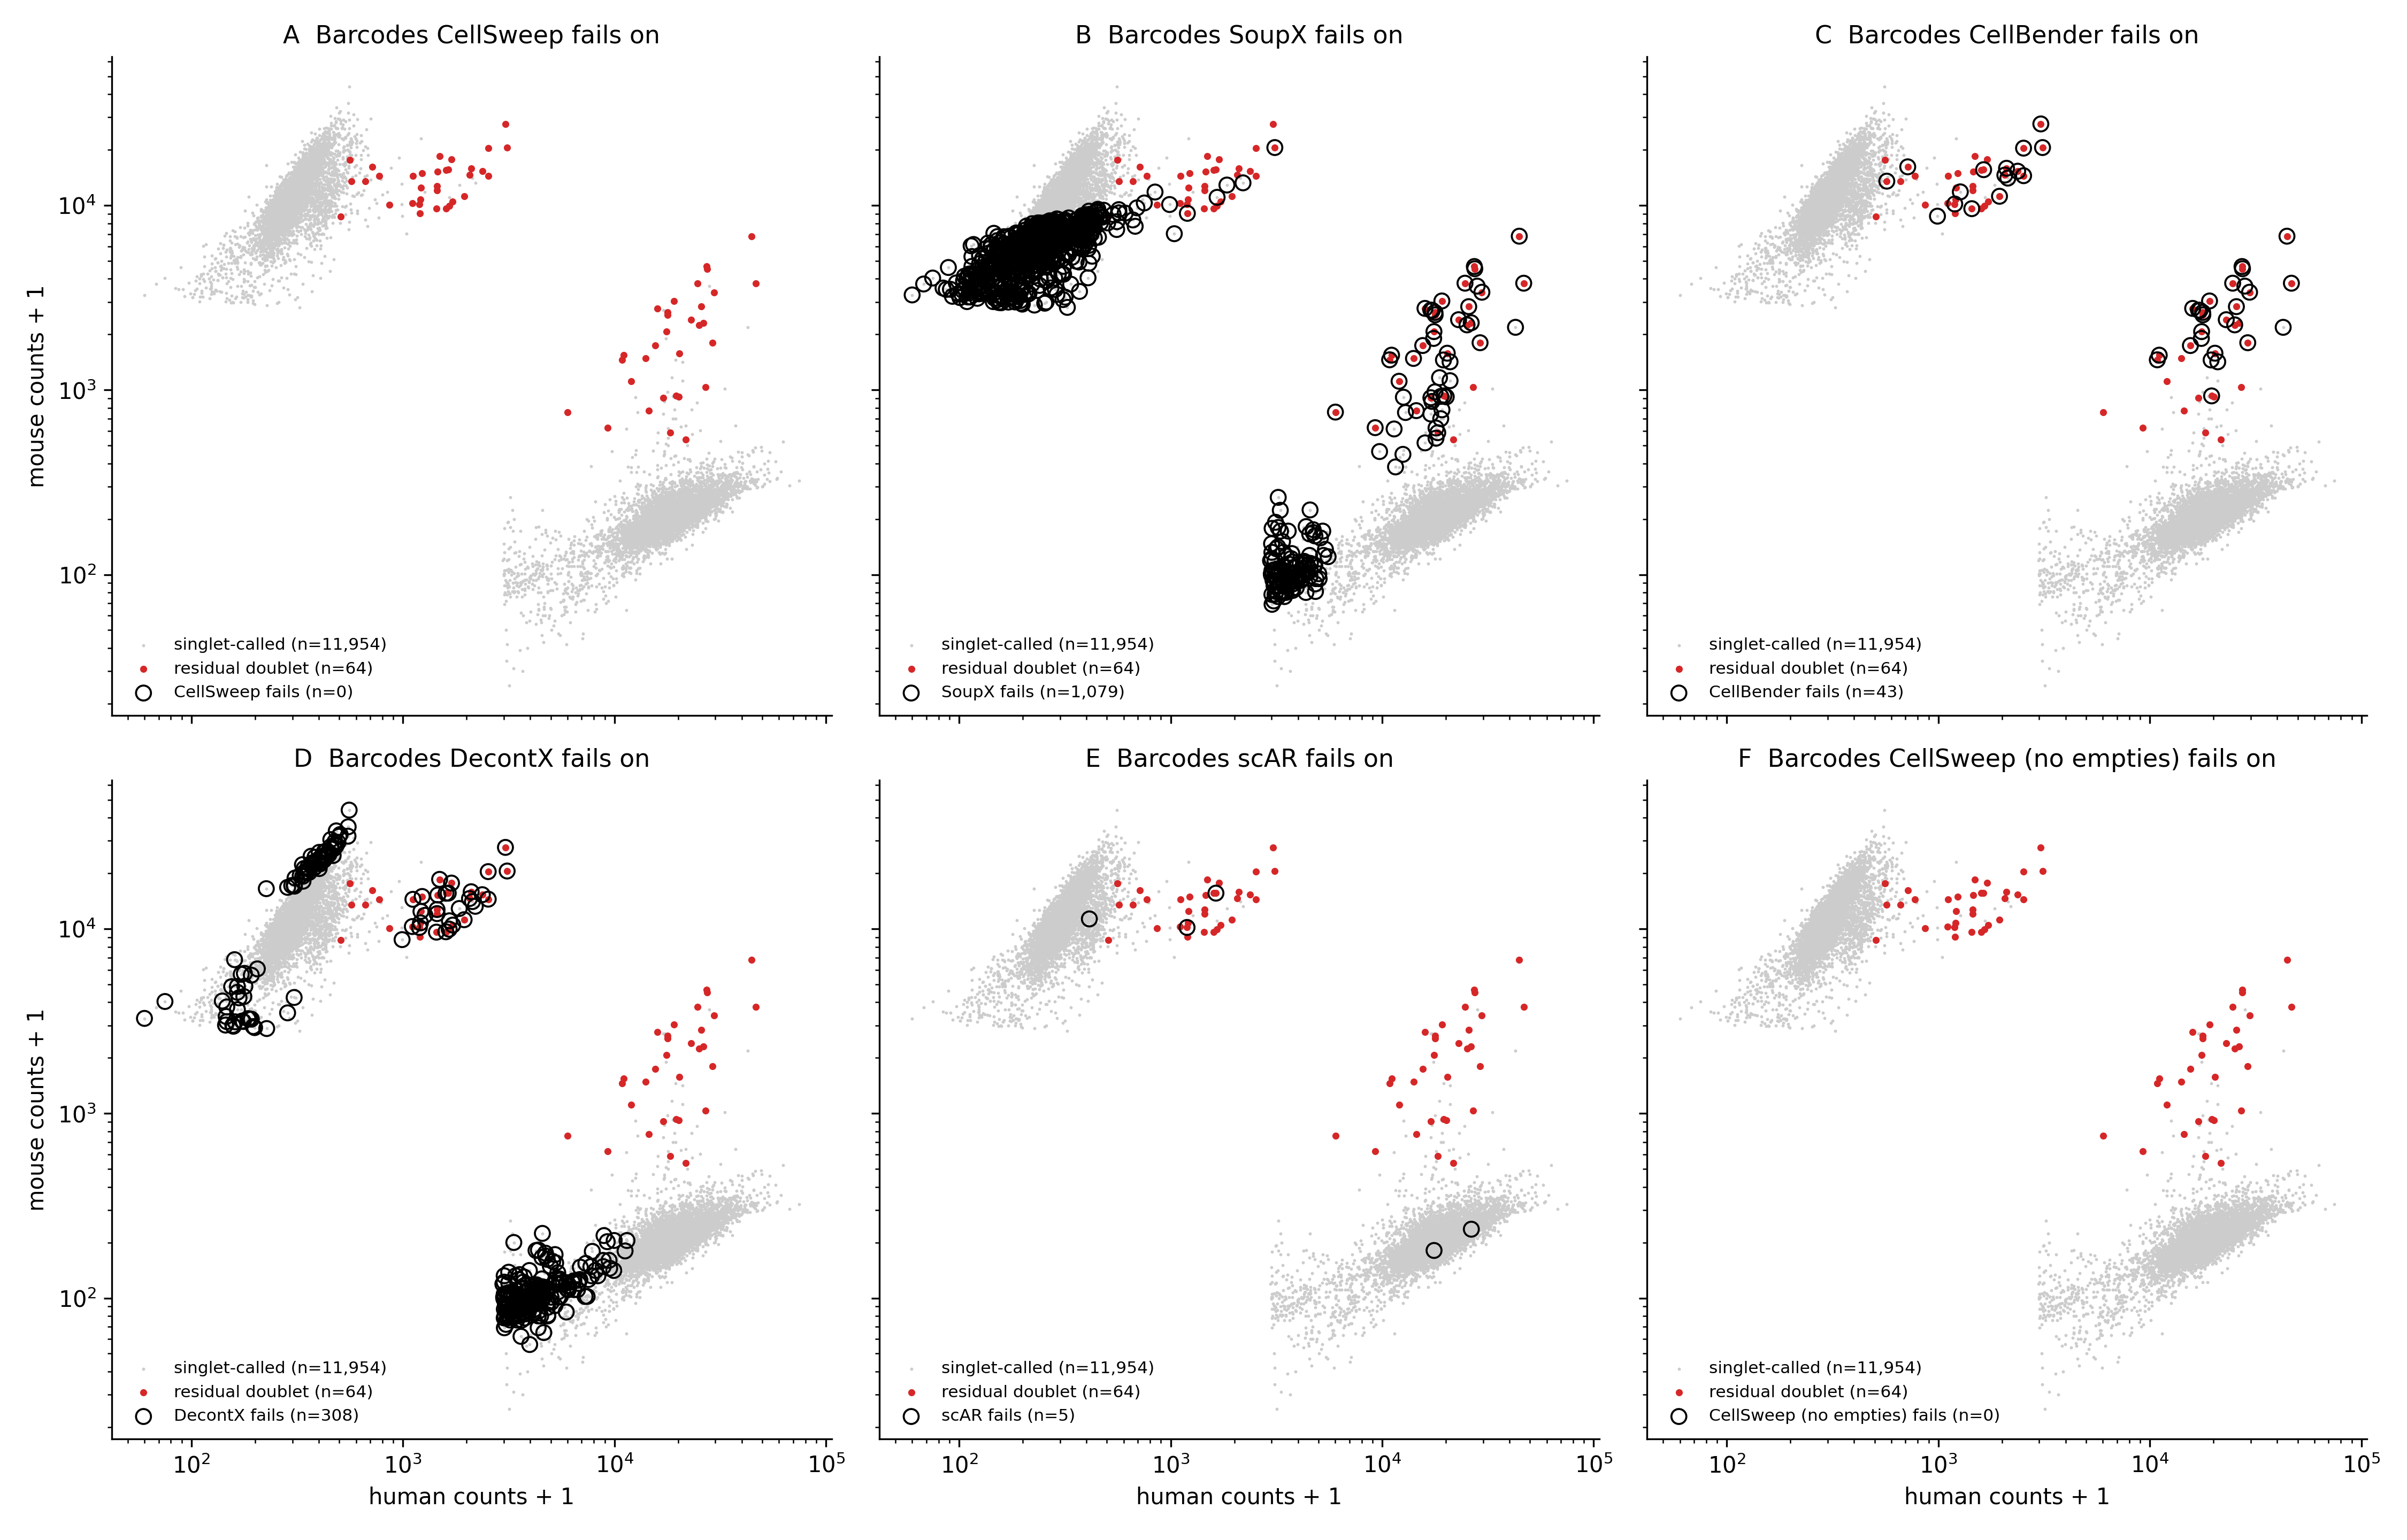

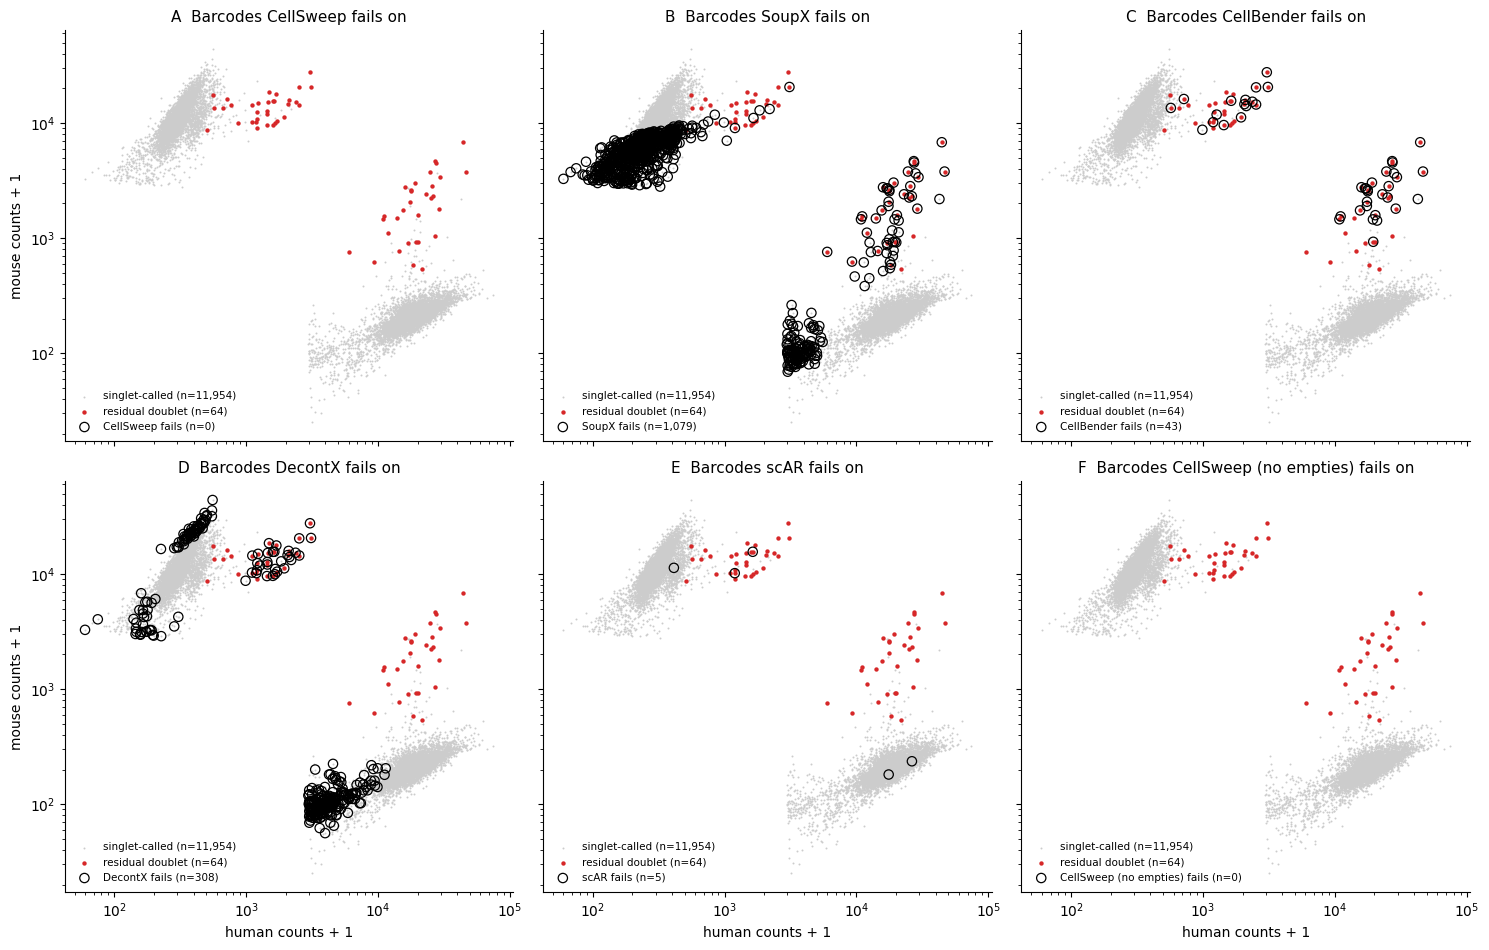

In [3]:
fm_csv = os.path.join(out_dir, "hgmm_12k_per_cell_failure_analysis.csv")
fm_npz = os.path.join(out_dir, "hgmm_12k_failure_analysis_controls.npz")
if os.path.exists(fm_csv) and os.path.exists(fm_npz) and not overwrite:
    fm_df = pd.read_csv(fm_csv, index_col=0)
    fm_synth = dict(np.load(fm_npz))
else:
    fm_df, fm_acs, fm_is_h, fm_is_m = build_table(data_dir)
    fm_df = fm_df[~fm_df.is_doublet].copy()      # doublets are removed before benchmarking
    fm_con, fm_cell, fm_pos = reference_profiles(fm_df, fm_acs, fm_is_h, fm_is_m)
    fm_df = fit_all(fm_df, fm_acs, fm_is_h, fm_is_m, fm_con, fm_cell, fm_pos)
    fm_synth = synthetic_controls(fm_df, fm_acs, fm_is_h, fm_is_m, fm_con, fm_cell, fm_pos)
    fm_df.to_csv(fm_csv)
    np.savez(fm_npz, **fm_synth)
print("simulated ambient-only: median w = %.3f, %.1f%% called as second cell"
      % (np.nanmedian(fm_synth["ambient"]), 100 * np.nanmean(fm_synth["ambient"] > 0.5)))
print("simulated doublet:      median w = %.3f, %.1f%% called as second cell"
      % (np.nanmedian(fm_synth["doublet"]), 100 * np.nanmean(fm_synth["doublet"] > 0.5)))
print("residual doublets: %d / %d (%.2f%%)"
      % (fm_df.residual_doublet.sum(), len(fm_df), 100 * fm_df.residual_doublet.mean()))
for t in FM_TOOLS:
    f = fm_df[f"{t}_rm"] < 0.5
    print("%-11s failures %4d | clean singlets %.2f%% | residual doublets %.1f%%"
          % (FM_TOOL_LABEL[t], f.sum(), 100 * f[~fm_df.residual_doublet].mean(), 100 * f[fm_df.residual_doublet].mean()))
fm_df = add_no_empties(fm_df, data_dir)
make_figure(fm_df, out_dir)
display(Image(os.path.join(out_dir, "hgmm_12k_per_tool_failures.png")))

## Flagging residual doublets with $\hat{\alpha}_i$

How well each per-barcode quantity separates the residual doublets from the other barcodes (area under the ROC curve; 0.5 = no separation).

In [4]:
from sklearn.metrics import roc_auc_score

y = fm_df["residual_doublet"].astype(int)
auc = pd.Series({"alpha_hat": roc_auc_score(y, fm_df["alpha_hat"]),
                 "library size": roc_auc_score(y, fm_df["raw_total"]),
                 "mitochondrial fraction": roc_auc_score(y, fm_df["mt_frac_raw"])}, name="AUC")
flag = fm_df["alpha_hat"] > 0.1
print(f"alpha_hat > 0.1 flags {int(flag.sum())} barcodes containing {100 * flag[fm_df.residual_doublet].mean():.0f}% of the residual doublets")
auc.round(3)

alpha_hat > 0.1 flags 134 barcodes containing 88% of the residual doublets


alpha_hat                 0.993
library size              0.648
mitochondrial fraction    0.498
Name: AUC, dtype: float64